In [90]:
import os
import gc
import glob
from pathlib import Path
from collections import Counter

import numpy as np
from statsmodels.stats.multitest import multipletests
from pybiomart import Dataset

import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
from matplotlib_venn import venn2, venn3

from upsetplot import from_contents, generate_counts, UpSet, plot, from_indicators
from pycirclize import Circos

import seaborn as sns

import anndata as ad
import scanpy as sc

%matplotlib inline

In [2]:
## FDR Calculation Function ##

def fdr_per_celltype(dge_df):
    """Add FDR-adjusted p-values and significance per cell type."""
    dge_df['p.adjusted'] = None
    dge_df['significant_fdr'] = False
    
    for celltype, group in dge_df.groupby('assay'):
        rejected, pvals_corrected, _, _ = multipletests(group['p.value'], method='fdr_bh')
        dge_df.loc[group.index, 'p.adjusted'] = pvals_corrected
        dge_df.loc[group.index, 'significant_fdr'] = rejected
    
    return dge_df

In [3]:
# ## Import AnnData Object ##

# adata = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata_annotated_w_celltypist_scanvi.h5ad')

# ## Toss Stressed Glia & Doublets ##

# adata = adata[~(adata.obs['subclass_annotations'] == 'Stressed Glia') & ~adata.obs['pred_dbl']].copy()
# gc.collect()

# # Create Pseudobulk Col ##

# adata.obs['Donor_Sample'] = adata.obs['Donor'].astype('str') + '_' + adata.obs['Sample Name'].astype('str')

In [78]:
## Get 22q11 Genes ##

dataset = Dataset(
    name='hsapiens_gene_ensembl',
    host='http://www.ensembl.org'
)

genes_22q11 = dataset.query(
    attributes=[
        'external_gene_name',
        'ensembl_gene_id',
        'gene_biotype',
        'chromosome_name',
        'start_position',
        'end_position'
    ],
    filters={
        'chromosome_name': ['22'],
        'start': 18924718,
        'end': 21111383
    }
)

genes_22q11 = genes_22q11.sort_values("Gene start (bp)")

x22q11_genes = genes_22q11[(genes_22q11['Gene type'] == 'protein_coding') & (genes_22q11['Gene name'].notnull())]['Gene name'].tolist()

  Gene name   Gene stable ID       Gene type  Chromosome/scaffold name  \
0       NaN  ENSG00000283809  protein_coding                        22   
1     PRODH  ENSG00000100033  protein_coding                        22   
2       NaN  ENSG00000284294          lncRNA                        22   
3       NaN  ENSG00000280418          lncRNA                        22   
4     DGCR5  ENSG00000273032          lncRNA                        22   

   Gene start (bp)  Gene end (bp)  
0         18906238       18947732  
1         18912696       18936451  
2         18936411       18947741  
3         18951934       18959512  
4         18969692       19031242  


In [110]:
## Get 15q13.3 deletion genes ##

dataset = Dataset(
    name='hsapiens_gene_ensembl',
    host='http://www.ensembl.org'
)

genes_15q13 = dataset.query(
    attributes=[
        'external_gene_name',
        'ensembl_gene_id',
        'gene_biotype',
        'chromosome_name',
        'start_position',
        'end_position'
    ],
    filters={
        'chromosome_name': ['15'],
        'start': 31000000,
        'end': 32500000
    }
)

genes_15q13 = genes_15q13.sort_values("Gene start (bp)")

x15q13_genes = (
    genes_15q13[
        (genes_15q13['Gene type'] == 'protein_coding') &
        (genes_15q13['Gene name'].notnull())
    ]['Gene name']
    .tolist()
)

print(x15q13_genes)

['TRPM1', 'KLF13', 'OTUD7A', 'CHRNA7', 'GOLGA8K', 'GOLGA8O']


In [111]:
## Get 3q29 deletion genes ##

genes_3q29 = dataset.query(
    attributes=[
        'external_gene_name',
        'ensembl_gene_id',
        'gene_biotype',
        'chromosome_name',
        'start_position',
        'end_position'
    ],
    filters={
        'chromosome_name': ['3'],
        'start': 195700000,
        'end': 197600000
    }
)

genes_3q29 = genes_3q29.sort_values("Gene start (bp)")

x3q29_genes = (
    genes_3q29[
        (genes_3q29['Gene type'] == 'protein_coding') &
        (genes_3q29['Gene name'].notnull())
    ]['Gene name']
    .tolist()
)

print(x3q29_genes)

['MUC20', 'MUC4', 'TNK2', 'TFRC', 'ZDHHC19', 'SLC51A', 'PCYT1A', 'DYNLT2B', 'TM4SF19-DYNLT2B', 'TM4SF19', 'UBXN7', 'RNF168', 'SMCO1', 'WDR53', 'FBXO45', 'NRROS', 'PIGX', 'CEP19', 'PAK2', 'SENP5', 'NCBP2', 'NCBP2AS2', 'PIGZ', 'MELTF', 'DLG1', 'BDH1']


In [9]:
# ## Known Genes In Deleted Regions ##

# # https://bioinfo.uth.edu/SZGR/display/showGeneset #

# CLASSIC_22q11 = ['TBX1', "COMT", "DGCR8", "TANGO2"]

# ALL_22q11 = ["DERL3", "LRP5L", "SGSM1", "C22orf15", "LOC284890", "C22orf36", "PIWIL3", "GSTT2B",
#                     "DDTL", "SMARCB1", "VPREB3", "SERPIND1", "HIRA", "ZNF74", "CLTCL1",
#                     "VPREB1", "GSTT2", "MMP11", "ZNF70", "CRYBB1", "CRKL", "BCR", "ADRBK2",
#                     "MN1", "CHEK2", "APOL2", "C22orf28", "LOC652968", "FBXO7", "PVALB", "PPARA",
#                     "TPST2", "PES1", "SEZ6L", "PITPNB", "TFIP11", "C22orf31", "ASPHD2", "KREMEN1",
#                     "ZNRF3", "ASCC2", "HSCB", "CCDC117", "RHBDD3", "C22orf24", "TIMP3", "TBC1D10A",
#                     "XBP1", "EWSR1", "LIF", "LIMK2", "DRG1", "NEFH", "NF2", "OSM",
#                     "RFPL1", "SMTN", "TCN2", "NIPSNAP1", "THOC5", "MTMR3", "GAL3ST1", "SFI1",
#                     "SF3A1", "RASL10A", "GAS2L1", "MORC2", "SEC14L2", "PATZ1", "PISD", "OSBP2",
#                     "RNF185", "PIK3IP1", "EMID1", "SELM", "HORMAD2", "DUSP18", "CABP7", "RNF215",
#                     "SEC14L3", "SEC14L4", "SLC35E4", "LOC550631", "SLC5A4", "C22orf30", "DGCR5",
#                     "DGCR6L", "SUSD2", "SCZD4", "BID", "IL17RA", "BCL2L13", "TUBA8", "GAB4",
#                     "CCT8L2", "XKR3", "TRMT2A", "RTDR1", "CECR2", "YPEL1", "LOC51233", "MED15",
#                     "UPB1", "CECR1", "DGCR8", "GNB1L", "EIF4ENIF1", "SLC2A11", "THAP7", "OR11H1",
#                     "C22orf13", "SLC25A18", "MYO18B", "CRYBB2", "CRYBB3", "CRYBA4", "PLA2G3",
#                     "APOL4", "ACO2", "ARVCF", "GSC2", "PI4KA", "SEPT5", "PRODH", "RANBP1",
#                     "SLC7A4", "SLC25A1", "TBX1", "CLDN5", "UBE2L3", "UFD1L", "CDC45L", "SNAP29",
#                     "DGCR2", "TXNRD2", "USP18", "HIC2", "TSSK2", "SDF2L1", "PPIL2", "ZDHHC8",
#                     "PEX26", "MICAL3", "MRPL40", "RTN4R", "C22orf29", "KLHL22", "SCARF2",
#                     "C22orf25", "AIFM3", "CCDC116", "FLJ42953", "LOC440792", "COMT", "GP1BB",
#                     "DGCR6", "LZTR1", "DGCR14", "GNAZ", "TOP3B", "RAB36", "PPM1F", "PRAME",
#                     "DKFZP434P211", "LOC96610", "ZNF280A", "ZNF280B", "ADORA2A", "DDT",
#                     "GGT1", "GSTT1", "IGLL1", "MIF", "SNRPD3", "SPECC1L", "CABIN1"]

# CLASSIC_3q29 = ['DLG1', "PAK2", "TFRC", "C3orf34"]
# BORDERLINE_3q29 = ['HES1', "CLDN1", "OPA1"]
# # ALL_3q29 = adata.var_names[adata.var_names.isin(CLASSIC_3q29 + BORDERLINE_3q29)].tolist()

# CLASSIC_15q13 = ['HERC2', 'CHRFAM7A', 'CHP', 'FMN1']
# BORDERLINE_15q13 = ['SCG5', 'SLC12A6', 'GREM1', 'MAP1A']
# # ALL_15q13 = adata.var_names[adata.var_names.isin(CLASSIC_15q13 + BORDERLINE_15q13)].tolist()

In [56]:
## Read in DEG Lists ##

CSV_PATH = '/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/disease_analyses/'

# by manuscript #
dge_fernando = pd.read_csv(Path(CSV_PATH) / 'dreamlet_fernando_dge_scz_results.csv')
dge_shin = pd.read_csv(Path(CSV_PATH) / 'dreamlet_shin_dge_scz_results.csv')
dge_purcell = pd.read_csv(Path(CSV_PATH) / 'dreamlet_purcell_dge_scz_results.csv')
dge_sebastian = pd.read_csv(Path(CSV_PATH) / 'dreamlet_sebastian_dge_scz_results.csv')
dge_sawada = pd.read_csv(Path(CSV_PATH) / 'dreamlet_sawada_dge_scz_results.csv')
dge_notaras = pd.read_csv(Path(CSV_PATH) / 'dreamlet_notaras_dge_scz_results.csv')
dge_rao = pd.read_csv(Path(CSV_PATH) / 'dreamlet_rao_dge_scz_results.csv')
dge_walsh_22q11 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_walsh_22q11_dge_scz_results.csv')
dge_walsh_15q13 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_walsh_15q13_dge_scz_results.csv')

# by disease #
dge_nrxn1 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_nrxn1_combined.csv')
dge_22q11 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_22q11_combined.csv')
dge_idiopathic = pd.read_csv(Path(CSV_PATH) / 'dreamlet_idiopathic_combined.csv')
dge_15q13 = dge_walsh_15q13
dge_3q29 = dge_purcell

In [55]:
# by disease #
dge_nrxn1_bulk = pd.read_csv(Path(CSV_PATH) / 'dreamlet_nrxn1_combined_bulk.csv')
dge_22q11_bulk = pd.read_csv(Path(CSV_PATH) / 'dreamlet_22q11_combined_bulk.csv')
dge_idiopathic_bulk = pd.read_csv(Path(CSV_PATH) / 'dreamlet_idiopathic_combined_bulk.csv')
dge_walsh_15q13 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_walsh_15q13_dge_scz_bulk_results.csv')
dge_3q29 = dge_purcell

In [57]:
# Make Assay ID #

# Put all dataframes in a dictionary
dge_dfs = {
    'dge_fernando': dge_fernando,
    'dge_shin': dge_shin,
    'dge_purcell': dge_purcell,
    'dge_sebastian': dge_sebastian,
    'dge_sawada': dge_sawada,
    'dge_notaras': dge_notaras,
    'dge_rao': dge_rao,
    'dge_walsh_22q11': dge_walsh_22q11,
    'dge_walsh_15q13': dge_walsh_15q13,
    'dge_nrxn1': dge_nrxn1,
    'dge_22q11': dge_22q11,
    'dge_idiopathic': dge_idiopathic,
    'dge_15q13': dge_15q13,
    'dge_3q29': dge_3q29}

# Add assay_ID column to each
for name, df in dge_dfs.items():
    df['assay_ID'] = df['assay'].astype(str) + ' | ' + df['ID'].astype(str)

In [14]:
## Calculate FDR ##

dge_nrxn1 = fdr_per_celltype(dge_nrxn1)
dge_22q11 = fdr_per_celltype(dge_22q11)
dge_idiopathic = fdr_per_celltype(dge_idiopathic)

In [121]:
dge_22q11_heatmap = pd.pivot(dge_22q11[dge_22q11['ID'].isin(x22q11_genes)], index='ID', columns='assay', values='estimate')

dge_nrxn1_heatmap = pd.pivot(dge_nrxn1[dge_nrxn1['ID'].isin(['NRXN1'])], index='ID', columns='assay', values='estimate')

dge_3q29_heatmap = pd.pivot(dge_3q29[dge_3q29['ID'].isin(x3q29_genes)], index='ID', columns='assay', values='logFC')

dge_15q13pt3_heatmap = pd.pivot(dge_15q13[dge_15q13['ID'].isin(x15q13_genes)], index='ID', columns='assay', values='logFC')

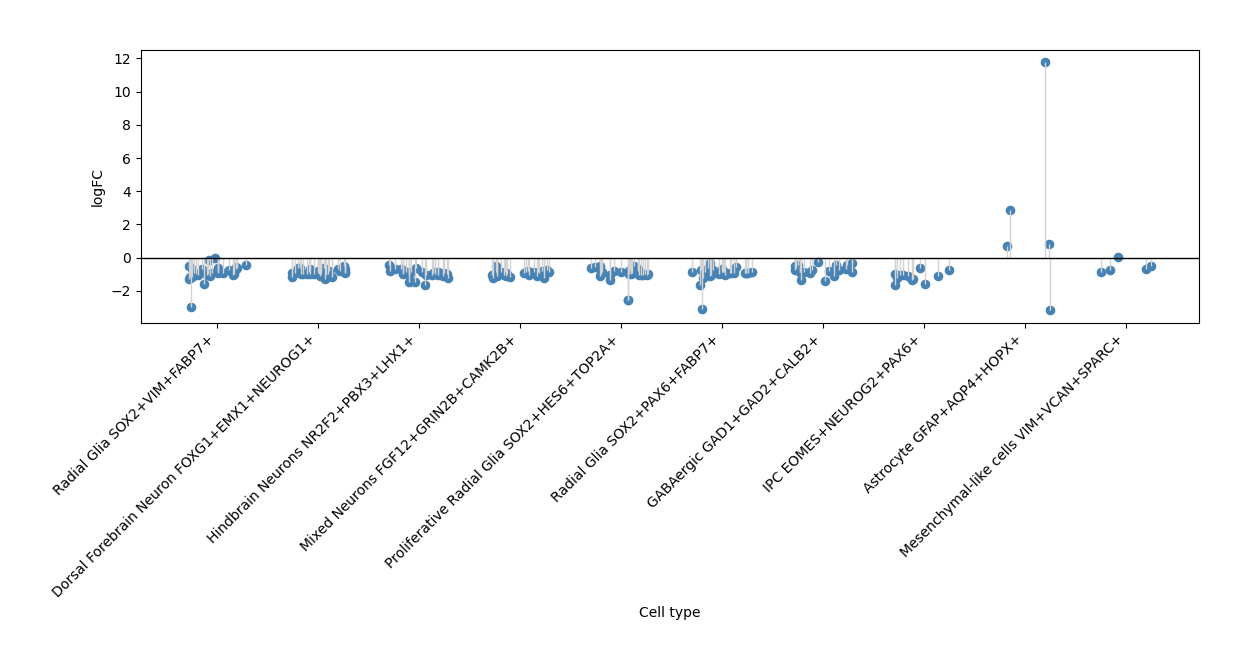

In [94]:
## Lollipop Plot ##

plot_df = dge_22q11[dge_22q11["ID"].isin(x22q11_genes)].copy()

# Numeric x positions for each assay
assays = plot_df["assay"].unique()
assay_to_x = {a: i for i, a in enumerate(assays)}
plot_df["x"] = plot_df["assay"].map(assay_to_x)

# Jitter within each assay
np.random.seed(42)
plot_df["x_jitter"] = plot_df["x"] + np.random.uniform(-0.3, 0.3, len(plot_df))

fig, ax = plt.subplots(figsize=(12, 6))

# Lollipop stems
ax.vlines(
    x=plot_df["x_jitter"],
    ymin=0,
    ymax=plot_df["estimate"],
    color="lightgray",
    linewidth=1
)

# Dots
ax.scatter(
    plot_df["x_jitter"],
    plot_df["estimate"],
    s=35,
    c="steelblue"
)

ax.axhline(0, color="black", lw=1)

ax.set_xticks(range(len(assays)))
ax.set_xticklabels(assays, rotation=45, ha="right")

ax.set_ylabel("logFC")
ax.set_xlabel("Cell type")

plt.tight_layout()
plt.show()

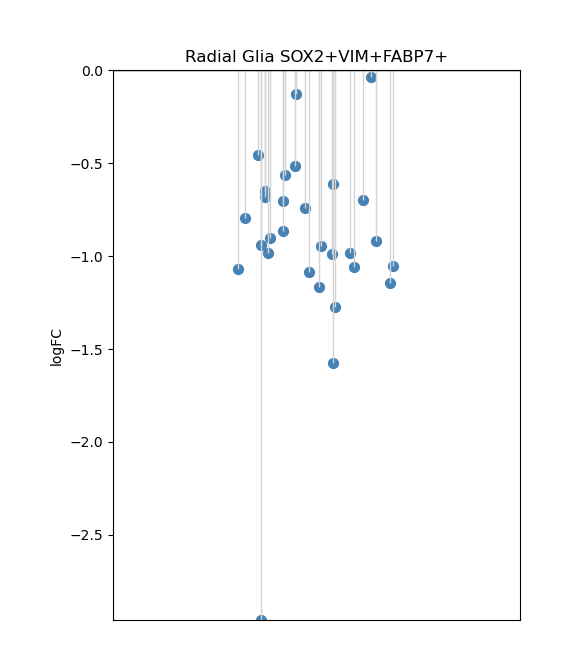

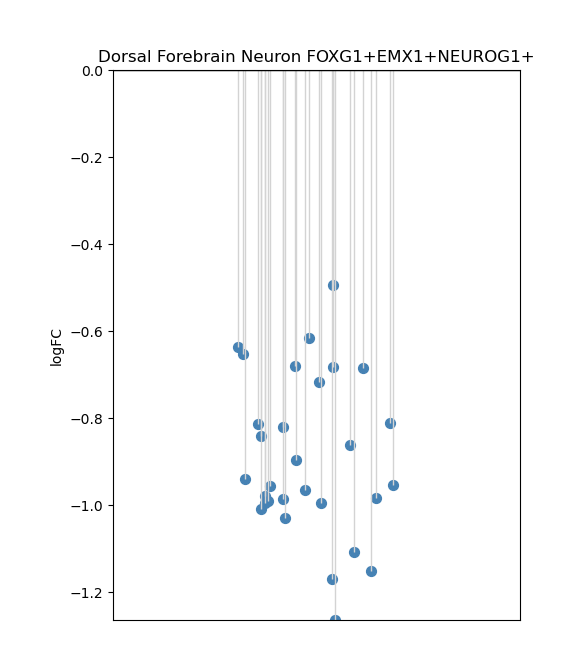

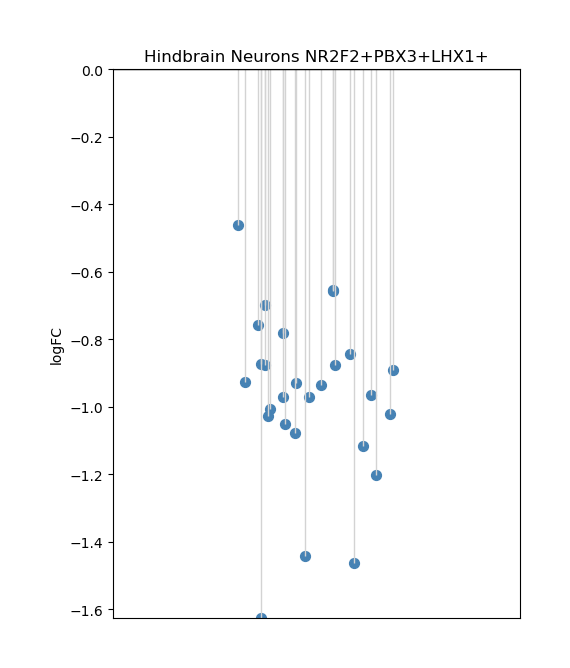

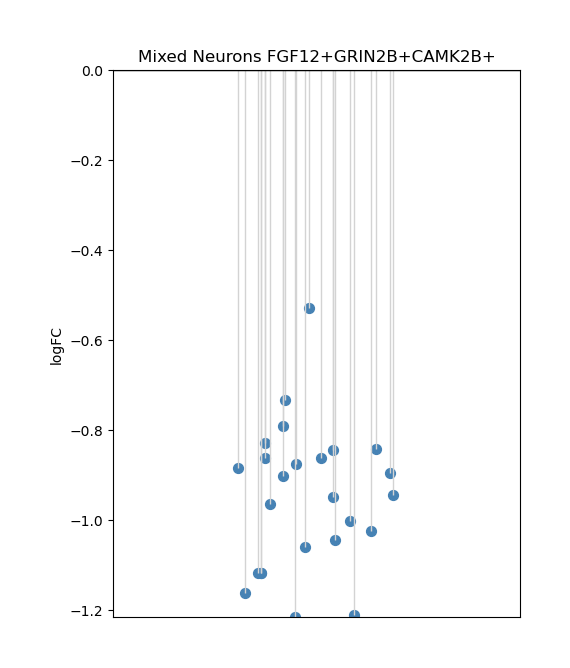

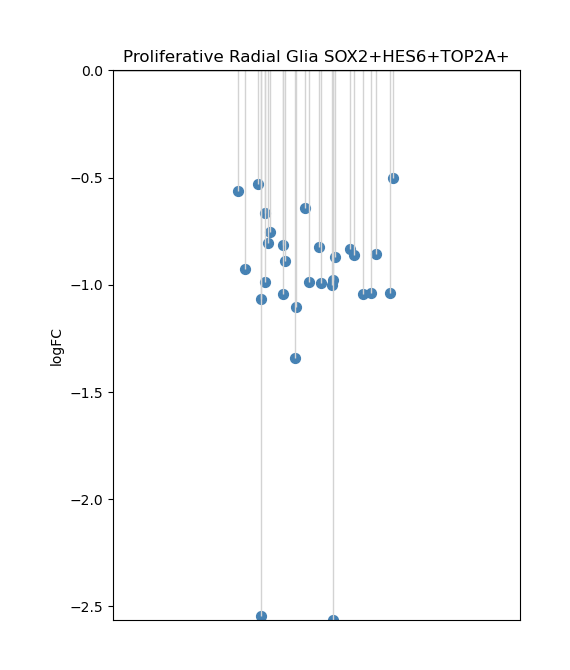

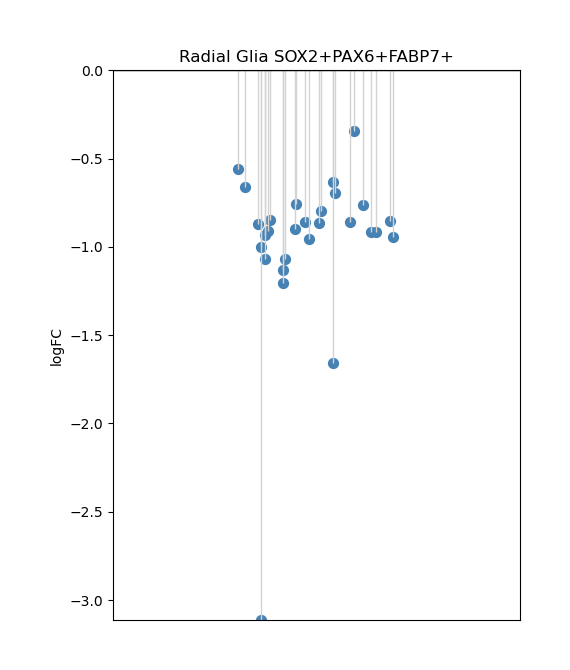

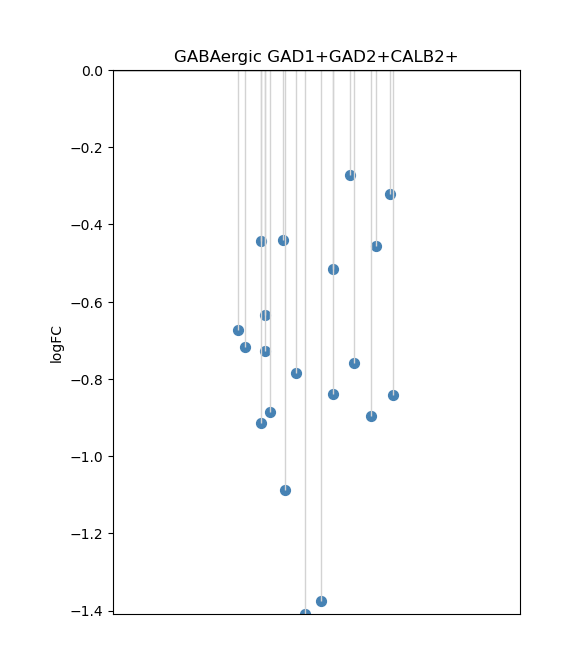

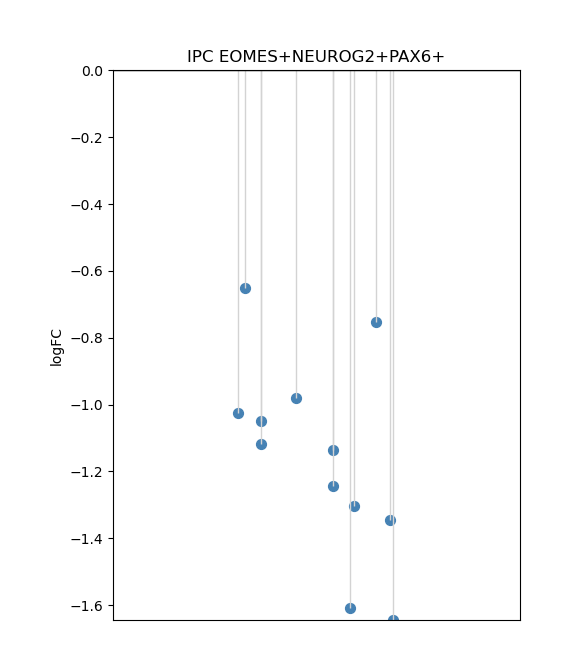

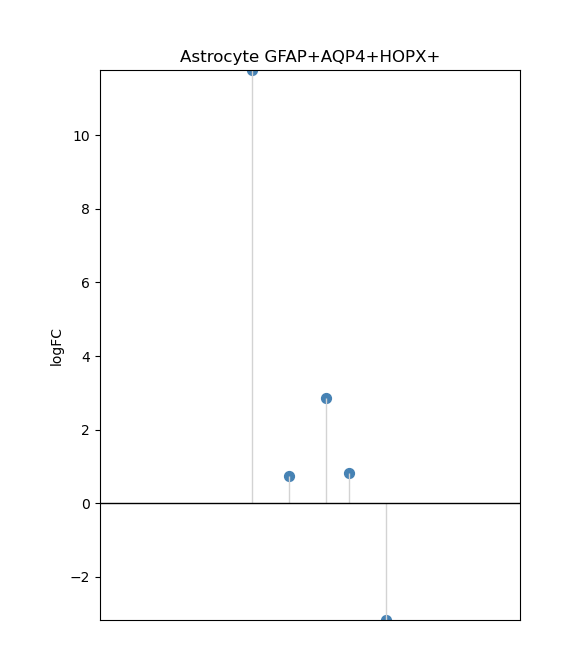

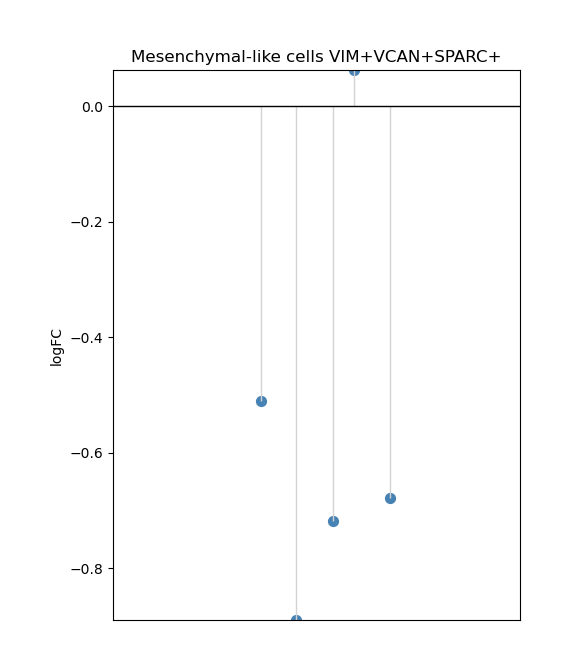

In [107]:

plot_df = dge_22q11[dge_22q11["ID"].isin(x22q11_genes)].copy()

# Iterate through each assay/cell type
for assay in plot_df["assay"].unique():
    
    temp_df = plot_df[plot_df["assay"] == assay].copy()
    
    # Jitter x positions
    np.random.seed(42)
    temp_df["x_jitter"] = np.random.uniform(-0.2, 0.2, len(temp_df))
    
    fig, ax = plt.subplots(figsize=(5, 6))
    
    # Lollipop stems
    ax.vlines(
        x=temp_df["x_jitter"],
        ymin=0,
        ymax=temp_df["estimate"],
        color="lightgray",
        linewidth=1
    )
    
    # Dots
    ax.scatter(
        temp_df["x_jitter"],
        temp_df["estimate"],
        s=50,
        c="steelblue"
    )
    
    # Zero line
    ax.axhline(0, color="black", lw=1)
    
    # Formatting
    ax.set_xlim(-0.5, 0.5)
    ax.set_ylabel("logFC")
    ax.set_title(assay)
    ax.set_xticks([])
    ax.set_xlabel("")
    
    # Make sure y-axis includes zero
    ymin, ymax = temp_df["estimate"].min(), temp_df["estimate"].max()
    ax.set_ylim(min(ymin, 0), max(ymax, 0))
    
    plt.tight_layout()
    plt.show()
    plt.close()

<Axes: xlabel='assay', ylabel='ID'>

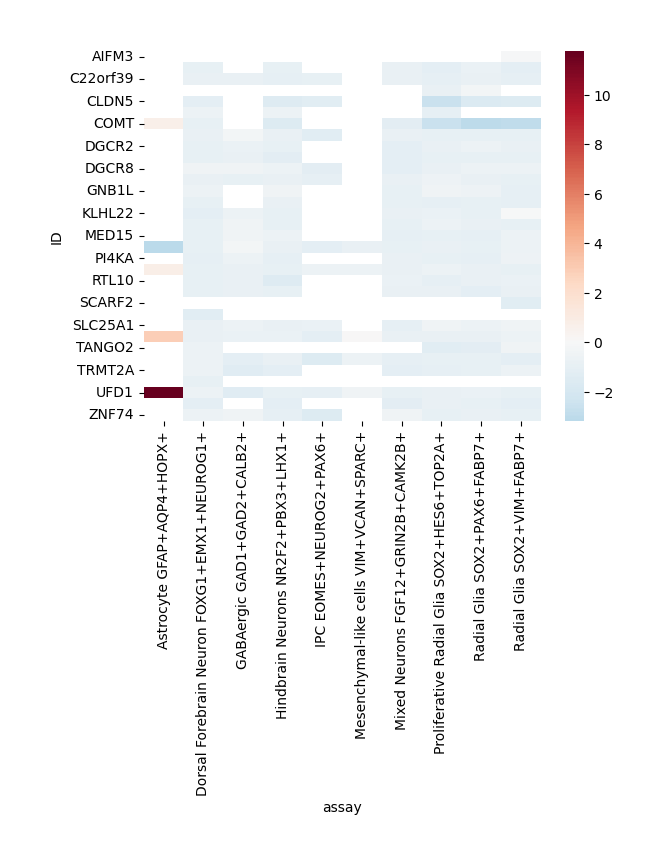

In [135]:
sns.heatmap(dge_22q11_heatmap, center=0, cmap='RdBu_r')

<Axes: xlabel='assay', ylabel='ID'>

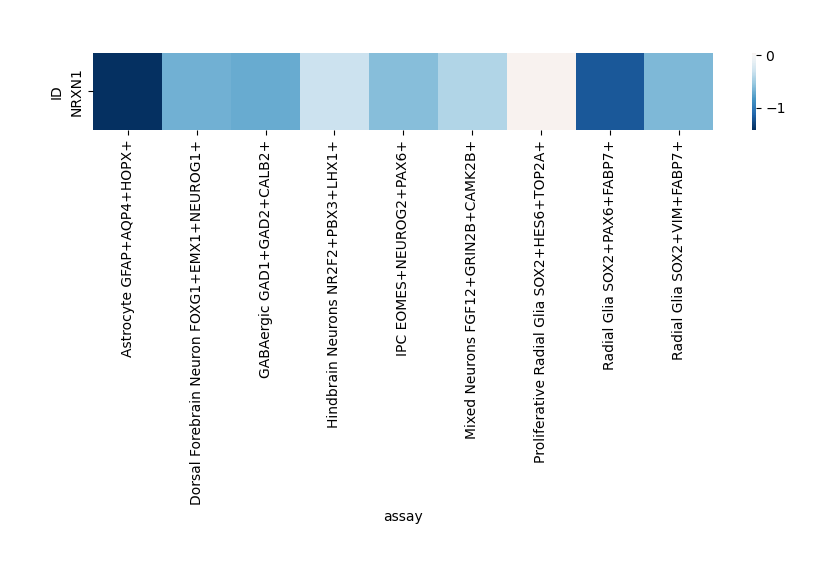

In [127]:
plt.figure(figsize=(10,1))

sns.heatmap(dge_nrxn1_heatmap, center=0, cmap='RdBu_r')

<Axes: xlabel='assay', ylabel='ID'>

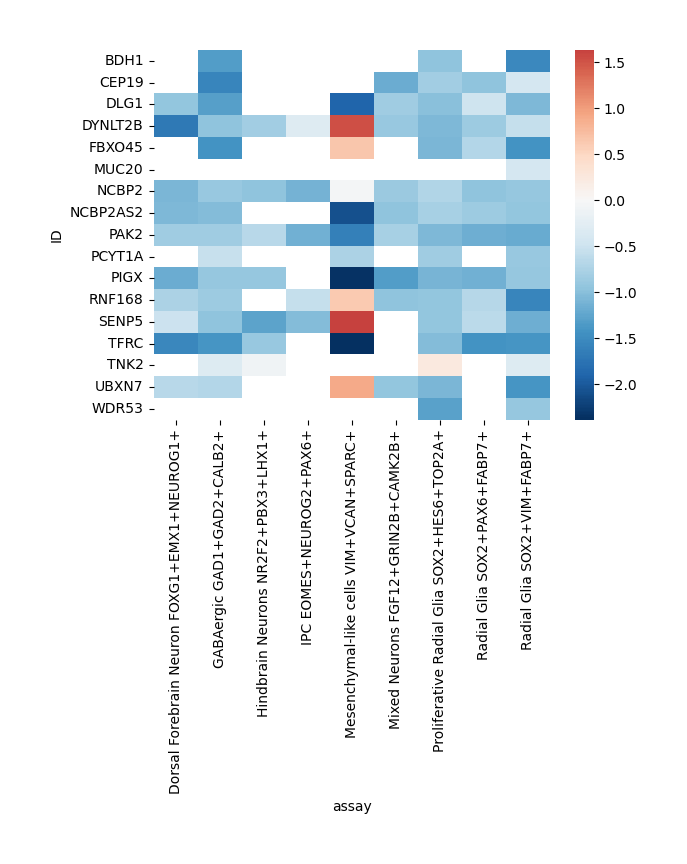

In [124]:
sns.heatmap(dge_3q29_heatmap, center=0, cmap='RdBu_r')

<Axes: xlabel='assay', ylabel='ID'>

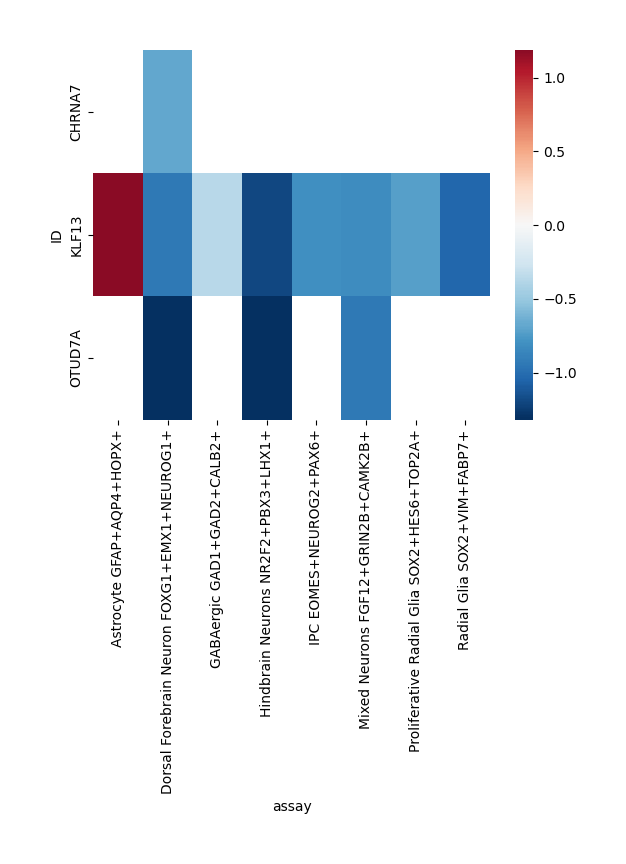

In [125]:
sns.heatmap(dge_15q13pt3_heatmap, center=0, cmap='RdBu_r')

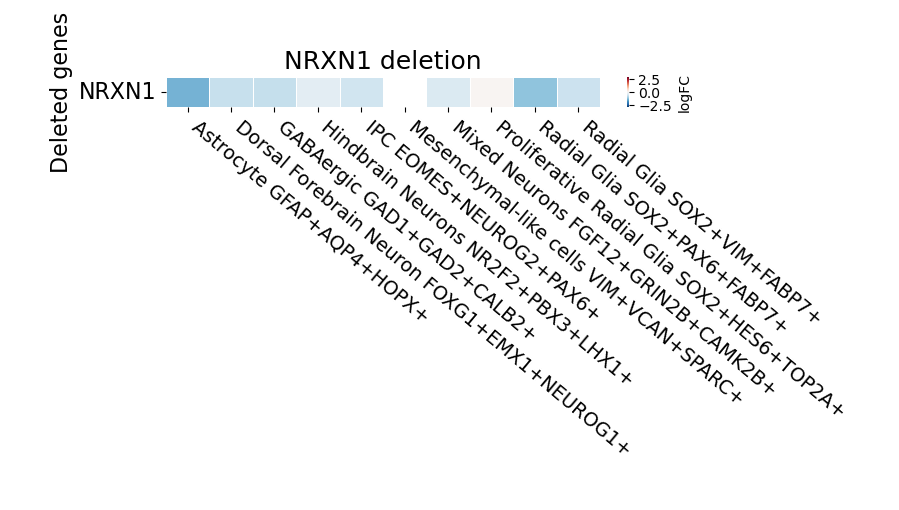

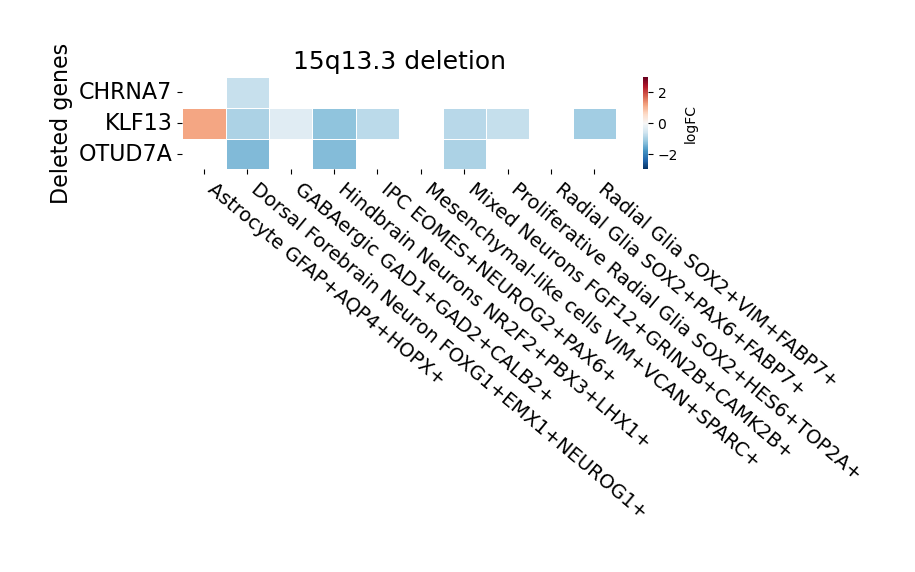

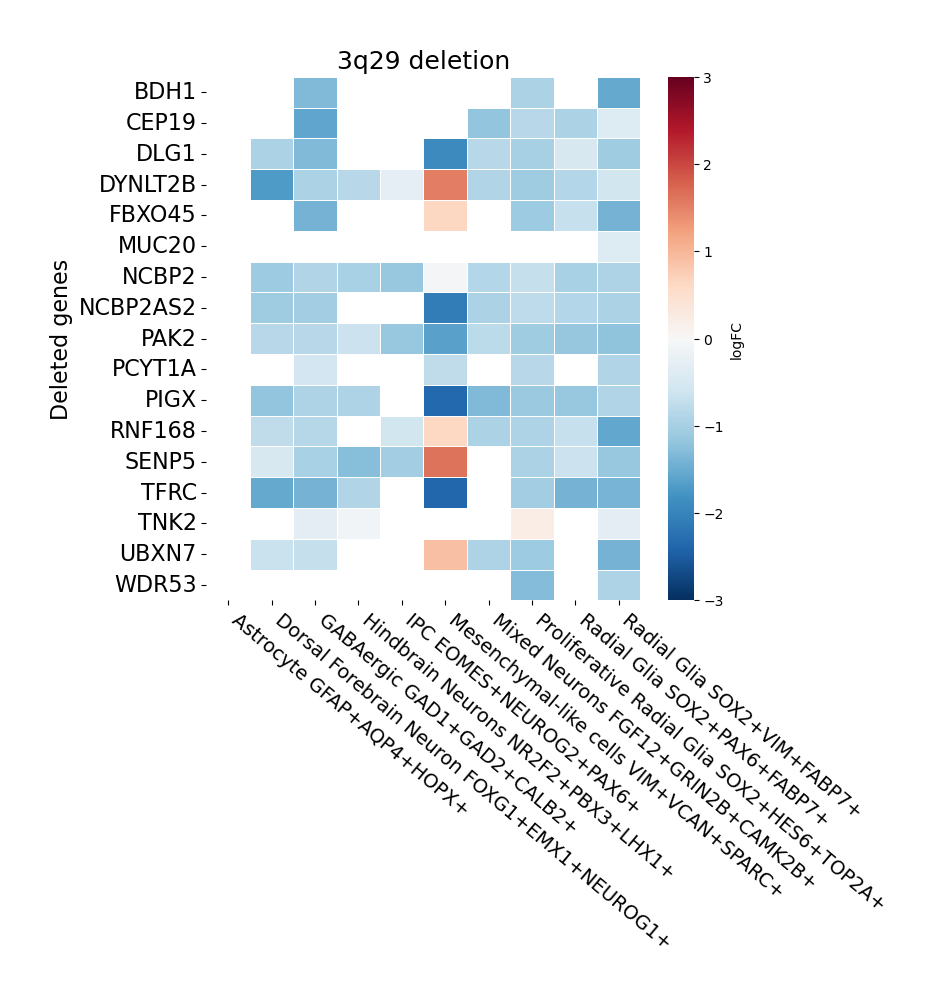

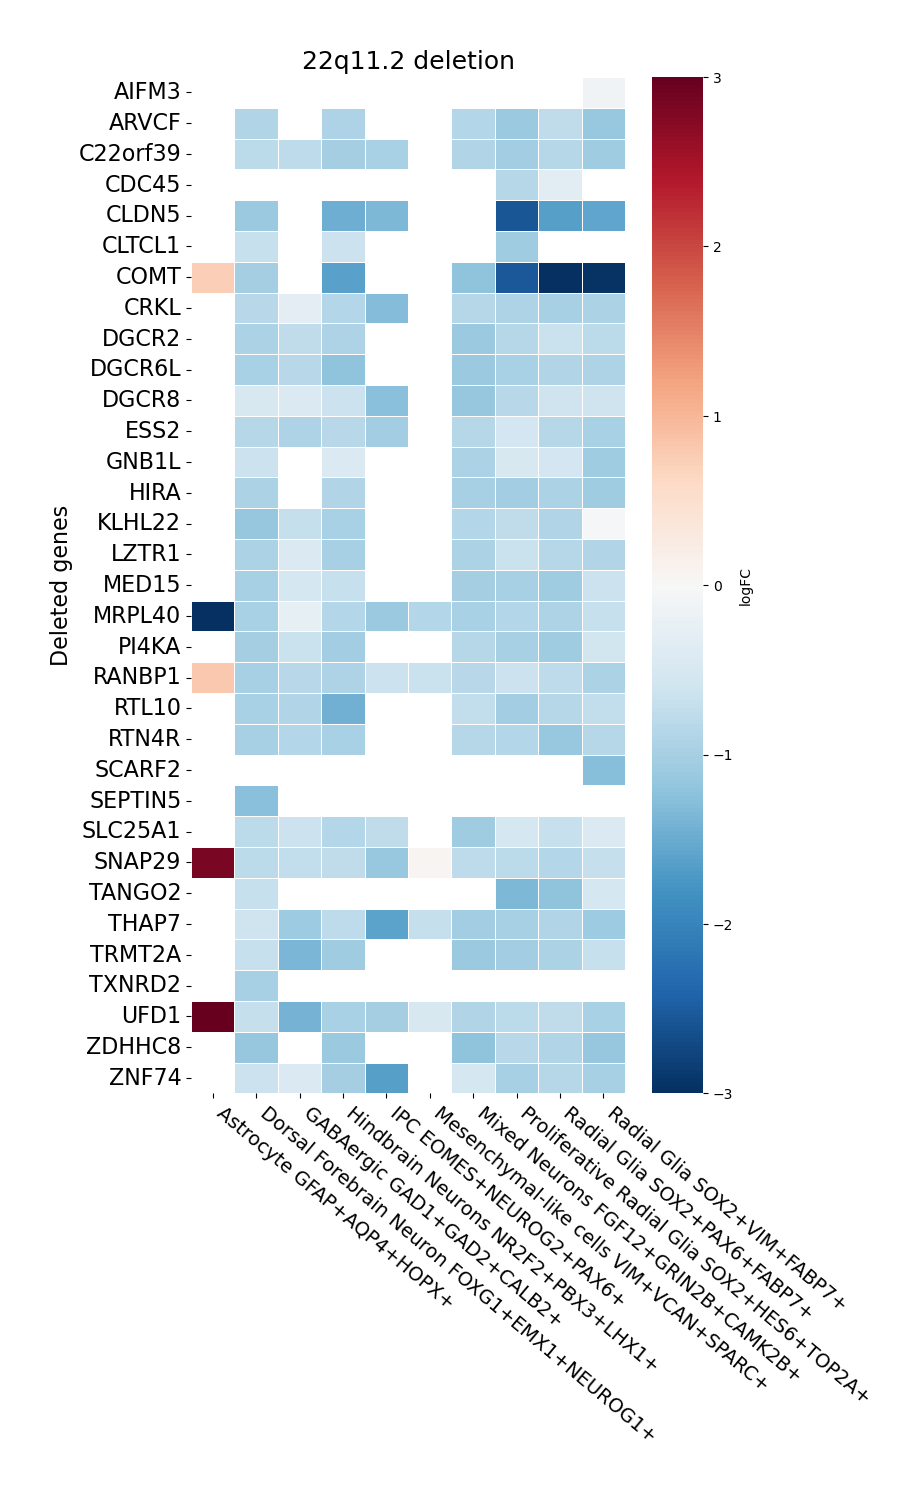

In [164]:
heatmaps = {
    "NRXN1 deletion": dge_nrxn1_heatmap,
    "15q13.3 deletion": dge_15q13pt3_heatmap,
    "3q29 deletion": dge_3q29_heatmap,
    "22q11.2 deletion": dge_22q11_heatmap
}

all_celltypes = sorted(
    set().union(*[df.columns for df in heatmaps.values()])
)

# Reindex every heatmap to the same columns
heatmaps_aligned = {
    name: df.reindex(columns=all_celltypes)
    for name, df in heatmaps.items()
}

for name, df in heatmaps_aligned.items():

    n_genes = df.shape[0]

    # inches per gene row
    row_height = 0.4

    fig_height = n_genes * row_height

    plt.figure(figsize=(df.shape[1]*.7, fig_height))

    sns.heatmap(
        df,
        cmap="RdBu_r",
        center=0,
        vmin=-3,
        vmax=3,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "logFC"}
    )

    plt.title(name, fontsize=18)
    plt.xlabel("")
    plt.ylabel("Deleted genes", fontsize=16)

    plt.xticks(rotation=-40, ha="left", fontsize=14)
    plt.yticks(rotation=0, fontsize=16)

    plt.savefig(f"/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Deleted_Region_{name}.svg", dpi=500,
                transparent=True,
                bbox_inches="tight")
    
    plt.show()
    plt.close()

In [161]:
heatmaps

{'NRXN1 deletion': assay  Astrocyte GFAP+AQP4+HOPX+  Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+  \
 ID                                                                              
 NRXN1                  -1.420465                                    -0.688047   
 
 assay  GABAergic GAD1+GAD2+CALB2+  Hindbrain Neurons NR2F2+PBX3+LHX1+  \
 ID                                                                      
 NRXN1                   -0.711245                           -0.309647   
 
 assay  IPC EOMES+NEUROG2+PAX6+  Mixed Neurons FGF12+GRIN2B+CAMK2B+  \
 ID                                                                   
 NRXN1                 -0.59846                            -0.42521   
 
 assay  Proliferative Radial Glia SOX2+HES6+TOP2A+  \
 ID                                                  
 NRXN1                                    0.051663   
 
 assay  Radial Glia SOX2+PAX6+FABP7+  Radial Glia SOX2+VIM+FABP7+  
 ID                                                            